# Experimental data

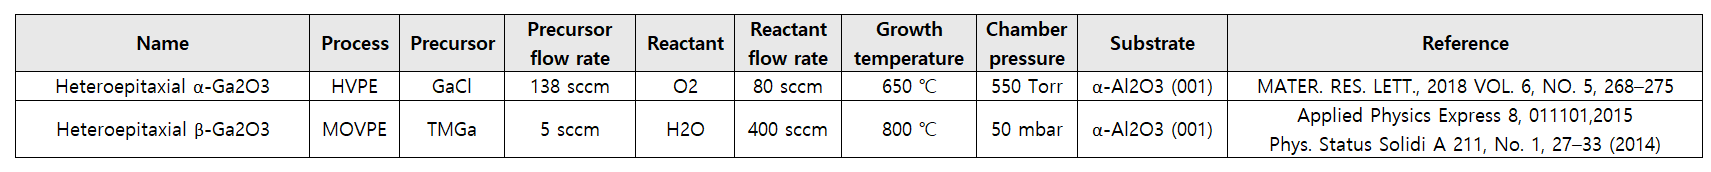

# 1. Calculating relative nucleation rates

In [134]:
import math
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib.patches import Wedge


In [135]:
# Physical constants
PI = math.pi
KB = 8.617e-2  # Boltzmann constant, unit: eV/K

def nucleation_rate(surface_meta, n_meta, surface_stable, n_stable, delta_g_rxn, bulk_diff, temp):
    """
    Calculate the nucleation rate
    
    Parameters:
    -----------
    surface_meta : float
        Surface energy of metastable phase (eV/Å²)
    n_meta : float
        Number of atoms per unit volume in metastable phase (atoms/Å³)
    surface_stable : float
        Surface energy of stable phase (eV/Å²)
    n_stable : float
        Number of atoms per unit volume in stable phase (atoms/Å³)
    delta_g_rxn : float
        Reaction free energy change (eV/atom)
    bulk_diff : float
        Bulk energy difference (eV/atom)
    temp : float
        Temperature (K)
    
    Returns:
    --------
    rate : float
        Calculated nucleation rate
    """
    try:
        # First term
        term1 = surface_meta**3 / (n_meta**2 * (delta_g_rxn + bulk_diff)**2)
        
        # Second term
        term2 = surface_stable**3 / (n_stable**2 * delta_g_rxn**2)
        
        # Constant coefficient in exponent
        constant = (16 * PI) / (3 * KB * temp)
        
        # Exponent
        exponent = constant * (term1 - term2)
        
        # Nucleation rate
        rate = np.exp(exponent)
        
        return rate
        
    except ZeroDivisionError:
        raise ValueError("Division by zero: n_meta, n_stable, delta_g_rxn, or temp cannot be zero.")
    except Exception as e:
        raise ValueError(f"Unexpected error occurred: {e}")

In [136]:
# Surfaced energy
b_surface = 48 # β-Ga2O3
b_surface_recon = 8 # Reconstruction energy of β-Ga2O3 (J. Mater. Chem. C, 2024, 12, 1820–1832)
a_surface = 62 # α-Ga2O3

# Vibrational energy difference
vib_E_diff_a_b = 26

# Strain energy differences
bulk_diff_a_b_al2o3 = -41.5 # on α-Al2O3 substrate
bulk_diff_a_b_ga2o3 = 0.7 # on α-Ga2O3 substrate

# Interface energy
inter_a_Al2O3 = -3 # Between α-Ga2O3 and α-Al2O3 (J. Mater. Chem. C, 2025, 13, 1469–1476)
inter_b_Al2O3 = 53 # Between β-Ga2O3 and α-Al2O3 (J. Mater. Chem. C, 2025, 13, 1469–1476)
inter_b_a_Ga2O3 = 47 #  Between β-Ga2O3 and α-Ga2O3  (J. Mater. Chem. C, 2025, 13, 1469–1476)

# Vibrational energy

# Density
density_b = 0.09092272200462186 # β-Ga2O3
density_b_al2o3 = 0.09997508965070419 # β-Ga2O3 on α-Al2O3
density_b_a_ga2o3 = 0.09355506403533614 # β-Ga2O3 on α-Ga2O3
density_a = 0.09897231179571023 # α-Ga2O3
density_a_al2o3 = 0.10584457530452702 # α-Ga2O3 on α-Al2O3

C:\Users\NB\AppData\Local\Temp\ipykernel_34080\1222736373.py:21: RuntimeWarning: divide by zero encountered in log
  y1 = np.log(nucleation_rate(
C:\Users\NB\AppData\Local\Temp\ipykernel_34080\3951799056.py:45: RuntimeWarning: overflow encountered in exp
  rate = np.exp(exponent)


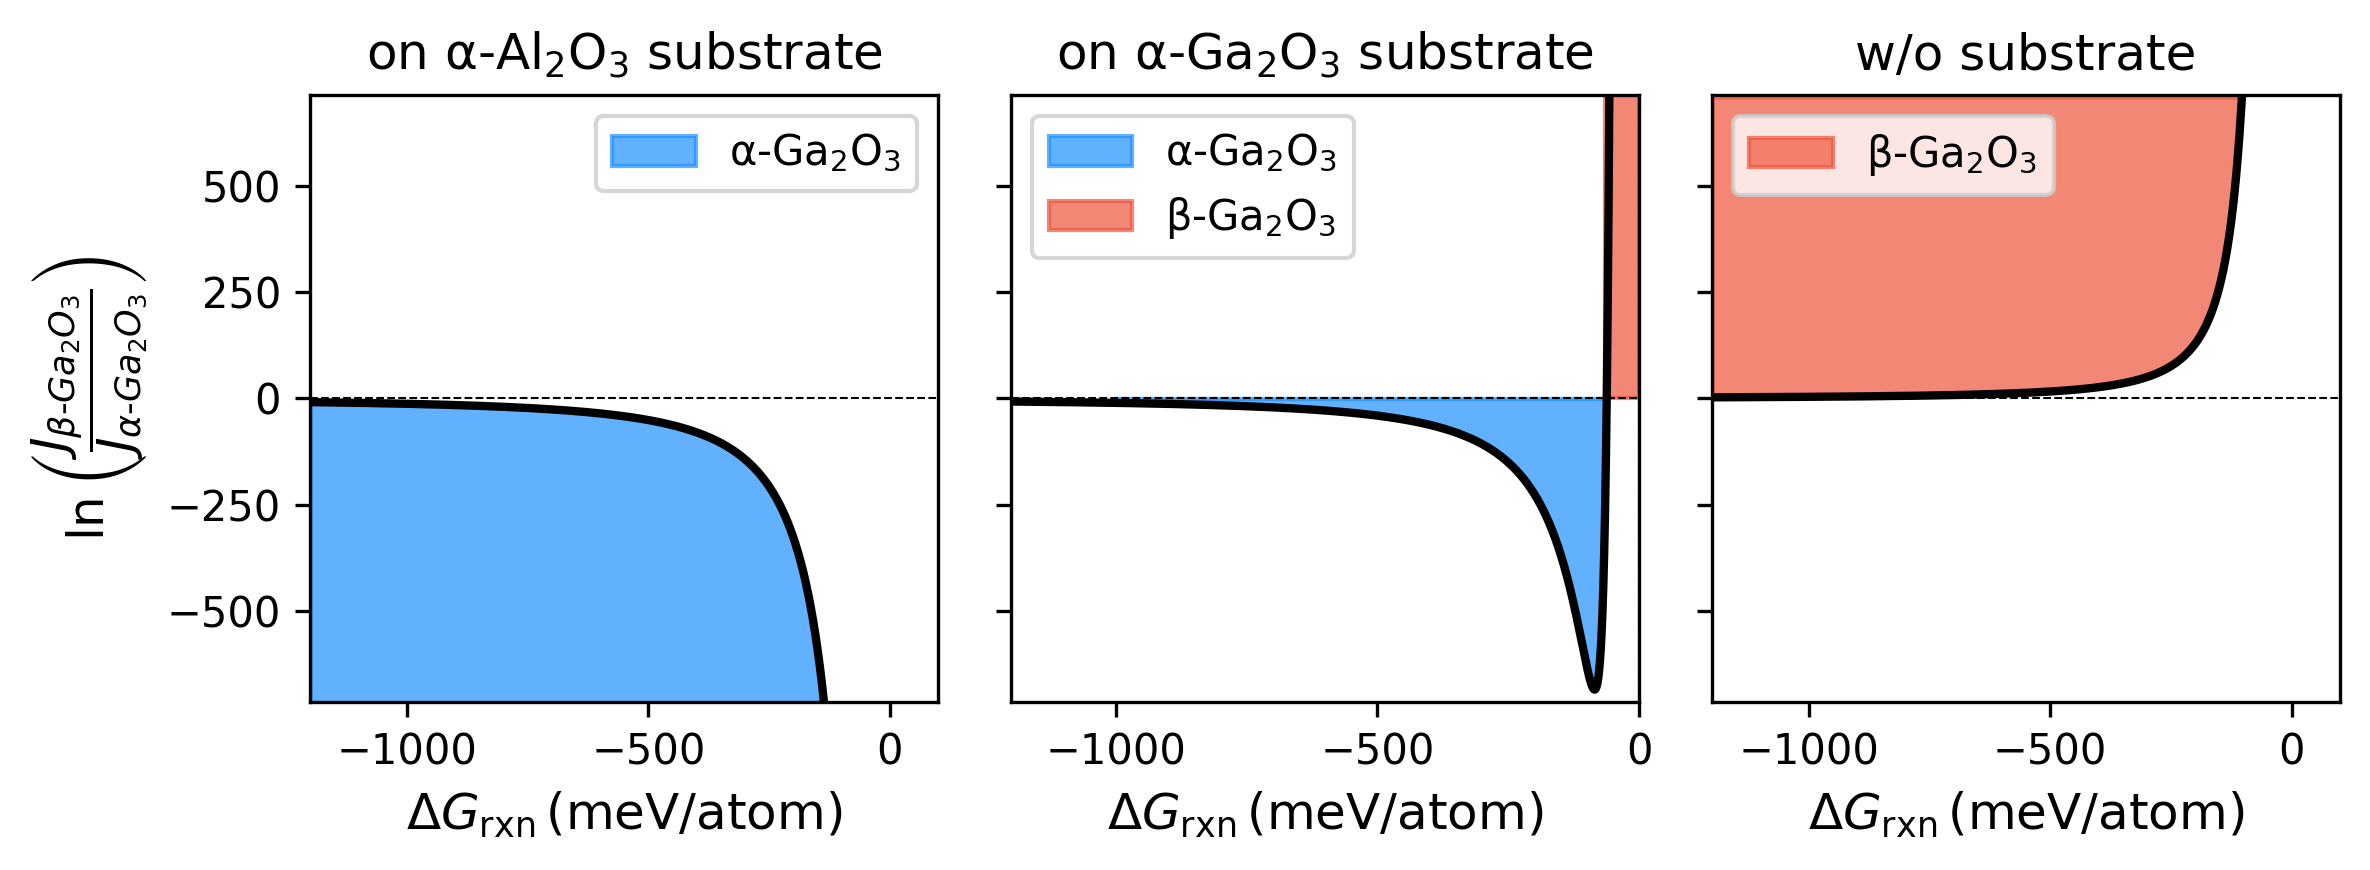

In [137]:
delta_g_rxn = np.arange(-1200, -50, 0.01)

lw = 2
fs = 12
ls = 10
xmin = -1200
xmax = 100
c1 = 'dodgerblue'
c2 = px.colors.qualitative.Plotly[1]

temp = 650 + 273 #We considered the α-Ga2O3 process condition of 650 °C and found that temperature does not significantly affect the relative nucleation rate.
# temp = 800 + 273 # We considered 

ymin, ymax = -715, 715

fig, axes = plt.subplots(1, 3, figsize=(8, 3), dpi=300, sharey=True)

# -----------------------
# (a) Al2O3 substrate
# -----------------------
y1 = np.log(nucleation_rate(
    a_surface, density_a_al2o3,
    b_surface - b_surface_recon + inter_b_Al2O3, density_b_al2o3,
    delta_g_rxn,
    bulk_diff_a_b_al2o3 + vib_E_diff_a_b,
    temp
))
axes[0].set_title("on α-Al$_2$O$_3$ substrate")

axes[0].plot(delta_g_rxn, y1, color='black', linewidth=lw)
axes[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axes[0].fill_betweenx(y1, delta_g_rxn, x2=min(delta_g_rxn),
                      alpha=0.7, color=c1,label="α-Ga$_2$O$_3$")

axes[0].set_xlim(xmin, xmax)
axes[0].set_ylim(ymin, ymax)
axes[0].set_xticks([-1000, -500, 0])
axes[0].tick_params(labelsize=ls)
axes[0].set_xlabel(r"$\Delta G_{\rm rxn}\,(\mathrm{meV/atom})$",fontsize=fs)
axes[0].set_ylabel(
    r"$\ln \left(\dfrac{J_{\beta\text{-}Ga_{2}O_{3}}}"
    r"{J_{\alpha\text{-}Ga_{2}O_{3}}}\right)$",fontsize=fs
)
axes[0].legend()
# -----------------------
# (b) α-Ga2O3 substrate
# -----------------------
axes[1].set_title("on α-Ga$_2$O$_3$ substrate")

y2 = np.log(nucleation_rate(
    a_surface, density_a,
    b_surface - b_surface_recon + inter_b_a_Ga2O3 , density_b_a_ga2o3,
    delta_g_rxn,
    bulk_diff_a_b_ga2o3 + vib_E_diff_a_b,
    temp
))

axes[1].plot(delta_g_rxn, y2, color='black', linewidth=lw)
axes[1].axhline(0, color='k', linestyle='--', linewidth=0.5)
axes[1].axvline(0, color='k', linestyle='--', linewidth=0.5)

delta_g_rxn2 = np.arange(-1000, -66, 0.01)
y2_fill = np.log(nucleation_rate(
    a_surface, density_a,
    b_surface - b_surface_recon + inter_b_a_Ga2O3, density_b_a_ga2o3,
    delta_g_rxn2,
    bulk_diff_a_b_ga2o3 + vib_E_diff_a_b,
    temp
))
axes[1].fill_between(delta_g_rxn2, y2_fill,
                     color=c1, alpha=0.7,label="α-Ga$_2$O$_3$")
axes[1].fill_between([-66, 0], [ymax, ymax],
                     alpha=0.7, color=c2,label="β-Ga$_2$O$_3$")

axes[1].set_xlim(xmin, 0)
axes[1].set_xticks([-1000, -500, 0])
axes[1].tick_params(labelsize=ls)
axes[1].set_xlabel(r"$\Delta G_{\rm rxn}\,(\mathrm{meV/atom})$",fontsize=fs)
axes[1].legend()

# -----------------------
# (c) No substrate
# -----------------------
axes[2].set_title("w/o substrate")
y3 = np.log(nucleation_rate(
    a_surface, density_a,
    b_surface - b_surface_recon, density_b,
    delta_g_rxn,
    vib_E_diff_a_b,
    temp
))

axes[2].plot(delta_g_rxn, y3, color='black', linewidth=lw)
axes[2].axhline(0, color='k', linestyle='--', linewidth=0.5)
axes[2].fill_betweenx(y3, delta_g_rxn, x2=min(delta_g_rxn),
                      alpha=0.7, color=c2,label="β-Ga$_2$O$_3$")

axes[2].set_xlim(xmin, xmax)
axes[2].set_xticks([-1000, -500, 0])
axes[2].tick_params(labelsize=ls)
axes[2].set_xlabel(r"$\Delta G_{\rm rxn}\,(\mathrm{meV/atom})$",fontsize=fs)
axes[2].legend()

plt.tight_layout()


### On the α-Ga₂O₃ substrate, phase competition is confirmed and possible reactions are explored.

# 2. Reaction pathfindings 

In [138]:
import numpy as np
import collections


from pymatgen.entries.computed_entries import ComputedEntry
from rxn_network.entries.entry_set import GibbsEntrySet
from rxn_network.enumerators.basic import BasicEnumerator
from rxn_network.entries.interpolated import InterpolatedEntry
import pandas as pds


In [139]:


# DFT-calculated Energies
# =============================================================================
# α-Ga2O3
# =============================================================================
# Precursors
GaCl = ComputedEntry("GaCl", -5.55531)
GaCl3 = ComputedEntry("GaCl3", -12.41599)  

# Reactants
O2 = ComputedEntry("O2", -9.8799) 

# Target
Ga2O3 = ComputedEntry("Ga2O3", -29.8385)  # beta phase

# By-products
Cl2 = ComputedEntry("Cl2", -3.59790)  # Cl2


# =============================================================================
# β-Ga2O3
# =============================================================================

# Precursors
TMGa = ComputedEntry("Ga(CH3)3", -62.32542)
DMGa = ComputedEntry("Ga(CH3)2", -40.94100)
MMGa = ComputedEntry("Ga(CH3)", -21.234229)


# Reactants
H2O = ComputedEntry("H2O", -14.233623)

# Target
Ga2O3 = ComputedEntry("Ga2O3", -29.8385)  # beta phase

# By-products
C2H4 = ComputedEntry("C2H4", -31.980520)
CH3 = ComputedEntry("CH3", -18.16748)
C2H5 = ComputedEntry("C2H5", -34.86254)
CH4 = ComputedEntry("CH4", -18.83721)
CO2 = ComputedEntry("C2O4", -22.969825)
H2 = ComputedEntry("H2", -6.7903) 

# Chemical potential of Ga
Ga = ComputedEntry("Ga8", -23.23820)

In [140]:
# =============================================================================
# Physical Constants
# =============================================================================
K_B = 1.380649e-23              # Boltzmann constant (J/K)
EV_PER_J = 1 / 1.60218e-19      # J to eV conversion
# MOLAR_VOLUME_STP = 22414        # cm³/mol at STP

# =============================================================================
# Functions
# =============================================================================

def ideal_gas_entry(entry, T, P, P0=1.0):
    """
    Apply ideal gas correction: E_corrected = E + kT*ln(P/P0)
    
    Parameters:
    -----------
    entry : ComputedEntry
    T : float - Temperature (K)
    P : float - Pressure (atm)
    P0 : float - Reference pressure (atm), default=1.0
    
    Returns:
    --------
    ComputedEntry with corrected energy
    """
    kT_J = K_B * T
    correction_J = kT_J * np.log(P / P0)
    correction_eV = correction_J * EV_PER_J
    
    corrected_energy = entry.energy + correction_eV
    return ComputedEntry(entry.composition, corrected_energy)


# α-Ga2O3
temp_alpha = 650+273
flow_precursor_alpha = 138 # SCCM
flow_reactant_alpha =  80 # SCCM
flow_total_alpha = flow_precursor_alpha + flow_reactant_alpha
P_chamber_alpha = 550 / 760 # Torr to atm

pp_precursor_alpha = (flow_precursor_alpha / flow_total_alpha) * P_chamber_alpha
pp_reactant_alpha = (flow_reactant_alpha / flow_total_alpha) * P_chamber_alpha

ideal_precursor_GaCl_alpha = ideal_gas_entry(GaCl,temp_alpha,pp_precursor_alpha)
ideal_precursor_GaCl3_alpha = ideal_gas_entry(GaCl3,temp_alpha,pp_precursor_alpha)
ideal_reactant_alpha = ideal_gas_entry(O2,temp_alpha,pp_reactant_alpha)

# β-Ga2O3

temp_beta = 800+273
flow_precursor_beta = 5 # SCCM
flow_reactant_beta = 400 # SCCM
flow_total_beta = flow_precursor_beta + flow_reactant_beta
P_chamber_beta = 50 / 1013.25 # mbar to atm

pp_precursor_beta = (flow_precursor_beta / flow_total_beta) * P_chamber_beta
pp_reactant_beta = (flow_reactant_beta / flow_total_beta) * P_chamber_beta

ideal_precursor_TMGa_beta = ideal_gas_entry(TMGa,temp_beta,pp_precursor_beta)
ideal_precursor_DMGa_beta = ideal_gas_entry(DMGa,temp_beta,pp_precursor_beta)
ideal_precursor_MMGa_beta = ideal_gas_entry(MMGa,temp_beta,pp_precursor_beta)
ideal_reactant_beta = ideal_gas_entry(H2O,temp_beta,pp_reactant_beta)


In [141]:
# α-Ga2O3 reaction generation

alpha_entries = [ideal_precursor_GaCl_alpha,
                ideal_precursor_GaCl3_alpha,
                ideal_reactant_alpha,
                Ga2O3,
                Cl2]

alpha_entries_inter = []

for entry in alpha_entries:
    entry_inter = InterpolatedEntry(entry.composition, entry.energy)
    alpha_entries_inter.append(entry_inter)

alpha_gibbs_entries = GibbsEntrySet(entries=alpha_entries_inter)

be_alpha = BasicEnumerator(n=3,precursors=[ideal_precursor_GaCl_alpha.composition,
                                           ideal_precursor_GaCl3_alpha.composition,
                                           ideal_reactant_alpha.composition],
                           targets=["Ga2O3"])
    
    
alpha_rxns = be_alpha.enumerate(alpha_gibbs_entries)


Building chunks...:   0%|          | 0/4 [00:00<?, ?it/s]

Enumerating reactions (BasicEnumerator): 100%|██████████| 1/1 [00:00<00:00, 25.89it/s]


In [142]:
beta_entries = [ideal_precursor_TMGa_beta,
                ideal_precursor_DMGa_beta,
                ideal_precursor_MMGa_beta,
                ideal_reactant_beta,
                Ga2O3,
                C2H4,CH3,C2H5,CH4,CO2,H2,Ga]

beta_entries_inter = []

for entry in beta_entries:
    entry_inter = InterpolatedEntry(entry.composition, entry.energy)
    beta_entries_inter.append(entry_inter)

beta_gibbs_entries = GibbsEntrySet(entries=beta_entries_inter)

be_beta = BasicEnumerator(n=3,precursors=[ideal_precursor_TMGa_beta.composition,
                                           ideal_precursor_DMGa_beta.composition,
                                           ideal_precursor_MMGa_beta.composition,
                                           ideal_reactant_beta.composition],
                           targets=["Ga2O3"])
    
    
beta_rxns = be_beta.enumerate(beta_gibbs_entries)



Building chunks...:   0%|          | 0/9 [00:00<?, ?it/s]

Enumerating reactions (BasicEnumerator): 100%|██████████| 6/6 [00:00<00:00, 18.20it/s]


In [143]:

            
data = collections.defaultdict(list)

for rxn in alpha_rxns:
    
    data["rxn"].append(rxn)
    Grxn =round(rxn.energy_per_atom*1000,2)
    data["ΔG_rxn (meV/atom)"].append(Grxn)
    
    for reactant in rxn.reactants:
        if reactant == ideal_precursor_GaCl_alpha.composition:
            data["Precursor"].append("GaCl")
        elif reactant == ideal_precursor_GaCl3_alpha.composition:
            data["Precursor"].append("GaCl3")
    
    data["Reactant"].append("O2")

    
    by_products = []  
    for product in rxn.products:
        if product != Ga2O3.composition: 
            by_products.append(product.reduced_formula)
            
    # data["By-Products"].append(by_products)
    data["By-products"].append(', '.join(str(p) for p in by_products))

for rxn in beta_rxns:
    data["rxn"].append(rxn)
    Grxn =round(rxn.energy_per_atom*1000,2)
    data["ΔG_rxn (meV/atom)"].append(Grxn)
    data["Precursor"].append("TMGa")
    # data["Reactants"].append("O2")
    
    for reactant in rxn.reactants:
        if reactant == O2.composition:
            data["Reactant"].append("O2")
        elif reactant == H2O.composition:
            data["Reactant"].append("H2O")
    

    by_products = []  
    for product in rxn.products:
        if product != Ga2O3.composition: 
            by_products.append(product.reduced_formula)
            
    data["By-products"].append(', '.join(str(p) for p in by_products))

df = pds.DataFrame(data, columns=["Precursor","Reactant","By-products","ΔG_rxn (meV/atom)","rxn"])
df.index = [''] * len(df)
df = df.sort_values('ΔG_rxn (meV/atom)')
df.insert(0, 'Reaction', range(1, len(df) + 1))

# print(df)

In [144]:
df

,Reaction,Precursor,Reactant,By-products,ΔG_rxn (meV/atom),rxn
,1,GaCl,O2,GaCl3,-1165.15,GaCl + 0.5 O2 -> 0.3333 Ga2O3 + 0.3333 GaCl3
,2,GaCl,O2,Cl2,-1031.94,GaCl + 0.75 O2 -> 0.5 Ga2O3 + 0.5 Cl2
,3,TMGa,H2O,"H2, Ga(H3C)3",-163.50,3 H2O + 3 GaH3C -> Ga2O3 + 3 H2 + Ga(H3C)3
,4,TMGa,H2O,"H2, Ga(H3C)3",-142.18,6 Ga(H3C)2 + 3 H2O -> Ga2O3 + 3 H2 + 4 Ga(H3C)3
,5,TMGa,H2O,"H2, H2C",-84.41,3 H2O + 2 GaH3C -> Ga2O3 + 4 H2 + 2 H2C
,6,TMGa,H2O,"H2, Ga(H3C)2",-77.46,3 H2O + 4 GaH3C -> Ga2O3 + 3 H2 + 2 Ga(H3C)2
,7,GaCl3,O2,Cl2,-63.45,2 GaCl3 + 1.5 O2 -> Ga2O3 + 3 Cl2
,8,TMGa,H2O,"H2, H5C2",-57.40,3 H2O + 2 GaH3C -> Ga2O3 + 3.5 H2 + H5C2
,9,TMGa,H2O,"H2, H2C",-35.59,2 Ga(H3C)2 + 3 H2O -> Ga2O3 + 5 H2 + 4 H2C
,10,TMGa,H2O,"H2, H5C2",2.42,2 Ga(H3C)2 + 3 H2O -> Ga2O3 + 4 H2 + 2 H5C2


In [145]:
# Filtering ΔG_rxn (meV/atom) range from -45 to -20 meV/atom
filtered_df = df[(df['ΔG_rxn (meV/atom)'] >= -1100) & (df['ΔG_rxn (meV/atom)'] <= -55)]
filtered_df

,Reaction,Precursor,Reactant,By-products,ΔG_rxn (meV/atom),rxn
,2,GaCl,O2,Cl2,-1031.94,GaCl + 0.75 O2 -> 0.5 Ga2O3 + 0.5 Cl2
,3,TMGa,H2O,"H2, Ga(H3C)3",-163.50,3 H2O + 3 GaH3C -> Ga2O3 + 3 H2 + Ga(H3C)3
,4,TMGa,H2O,"H2, Ga(H3C)3",-142.18,6 Ga(H3C)2 + 3 H2O -> Ga2O3 + 3 H2 + 4 Ga(H3C)3
,5,TMGa,H2O,"H2, H2C",-84.41,3 H2O + 2 GaH3C -> Ga2O3 + 4 H2 + 2 H2C
,6,TMGa,H2O,"H2, Ga(H3C)2",-77.46,3 H2O + 4 GaH3C -> Ga2O3 + 3 H2 + 2 Ga(H3C)2
,7,GaCl3,O2,Cl2,-63.45,2 GaCl3 + 1.5 O2 -> Ga2O3 + 3 Cl2
,8,TMGa,H2O,"H2, H5C2",-57.40,3 H2O + 2 GaH3C -> Ga2O3 + 3.5 H2 + H5C2


In [157]:
# df.to_excel("Hetero_alpha_rxn.xlsx")

In [147]:
# We confirmed that Reactions 2 (GaCl) and 8 (TMGa) fall within an appropriate energy range to serve as kinetic drivers.

# Reaction 2 (GaCl)
R_2 = df[df['Reaction'] == 2][['Precursor', 'ΔG_rxn (meV/atom)']]
R_2_precursor = R_2['Precursor'].values[0]
R_2_Grxn = R_2['ΔG_rxn (meV/atom)'].values[0]

# Reaction 8 (TMGa)
R_8 = df[df['Reaction'] == 8][['Precursor', 'ΔG_rxn (meV/atom)']]
R_8_precursor = R_8['Precursor'].values[0]
R_8_Grxn = R_8['ΔG_rxn (meV/atom)'].values[0]


In [148]:
# =============================================================================
# Calculate Nucleation Rates at Reaction Points
# =============================================================================

# ln(J) ratio for Reaction 2
ln_J_ratio_R_2 = np.log(nucleation_rate(
    a_surface, density_a, 
    b_surface - b_surface_recon + inter_b_a_Ga2O3 , density_b_a_ga2o3, 
    R_2_Grxn,  
    bulk_diff_a_b_ga2o3 + vib_E_diff_a_b, 
    temp
))

# ln(J) ratio for Reaction 8
ln_J_ratio_R_8 = np.log(nucleation_rate(
    a_surface, density_a, 
    b_surface - b_surface_recon + inter_b_a_Ga2O3 , density_b_a_ga2o3, 
    R_8_Grxn,  
    bulk_diff_a_b_ga2o3 + vib_E_diff_a_b, 
    temp
))

# =============================================================================
# Summary
# =============================================================================
print(f"Reaction 2 ({R_2_precursor}):")
print(f"  ΔG_rxn = {R_2_Grxn:.2f} meV/atom")
print(f"  ln(J_ratio) = {ln_J_ratio_R_2:.4f}")

print(f"\nReaction 5 ({R_8_precursor}):")
print(f"  ΔG_rxn = {R_8_Grxn:.2f} meV/atom")
if np.isinf(ln_J_ratio_R_8):
    print(f"  ln(J_ratio) = ∞ (infinite)")
else:
    print(f"  ln(J_ratio) = {ln_J_ratio_R_8:.4f}")

Reaction 2 (GaCl):
  ΔG_rxn = -1031.94 meV/atom
  ln(J_ratio) = -9.8113

Reaction 5 (TMGa):
  ΔG_rxn = -57.40 meV/atom
  ln(J_ratio) = 627.7821


C:\Users\NB\AppData\Local\Temp\ipykernel_34080\3951799056.py:45: RuntimeWarning: overflow encountered in exp
  rate = np.exp(exponent)


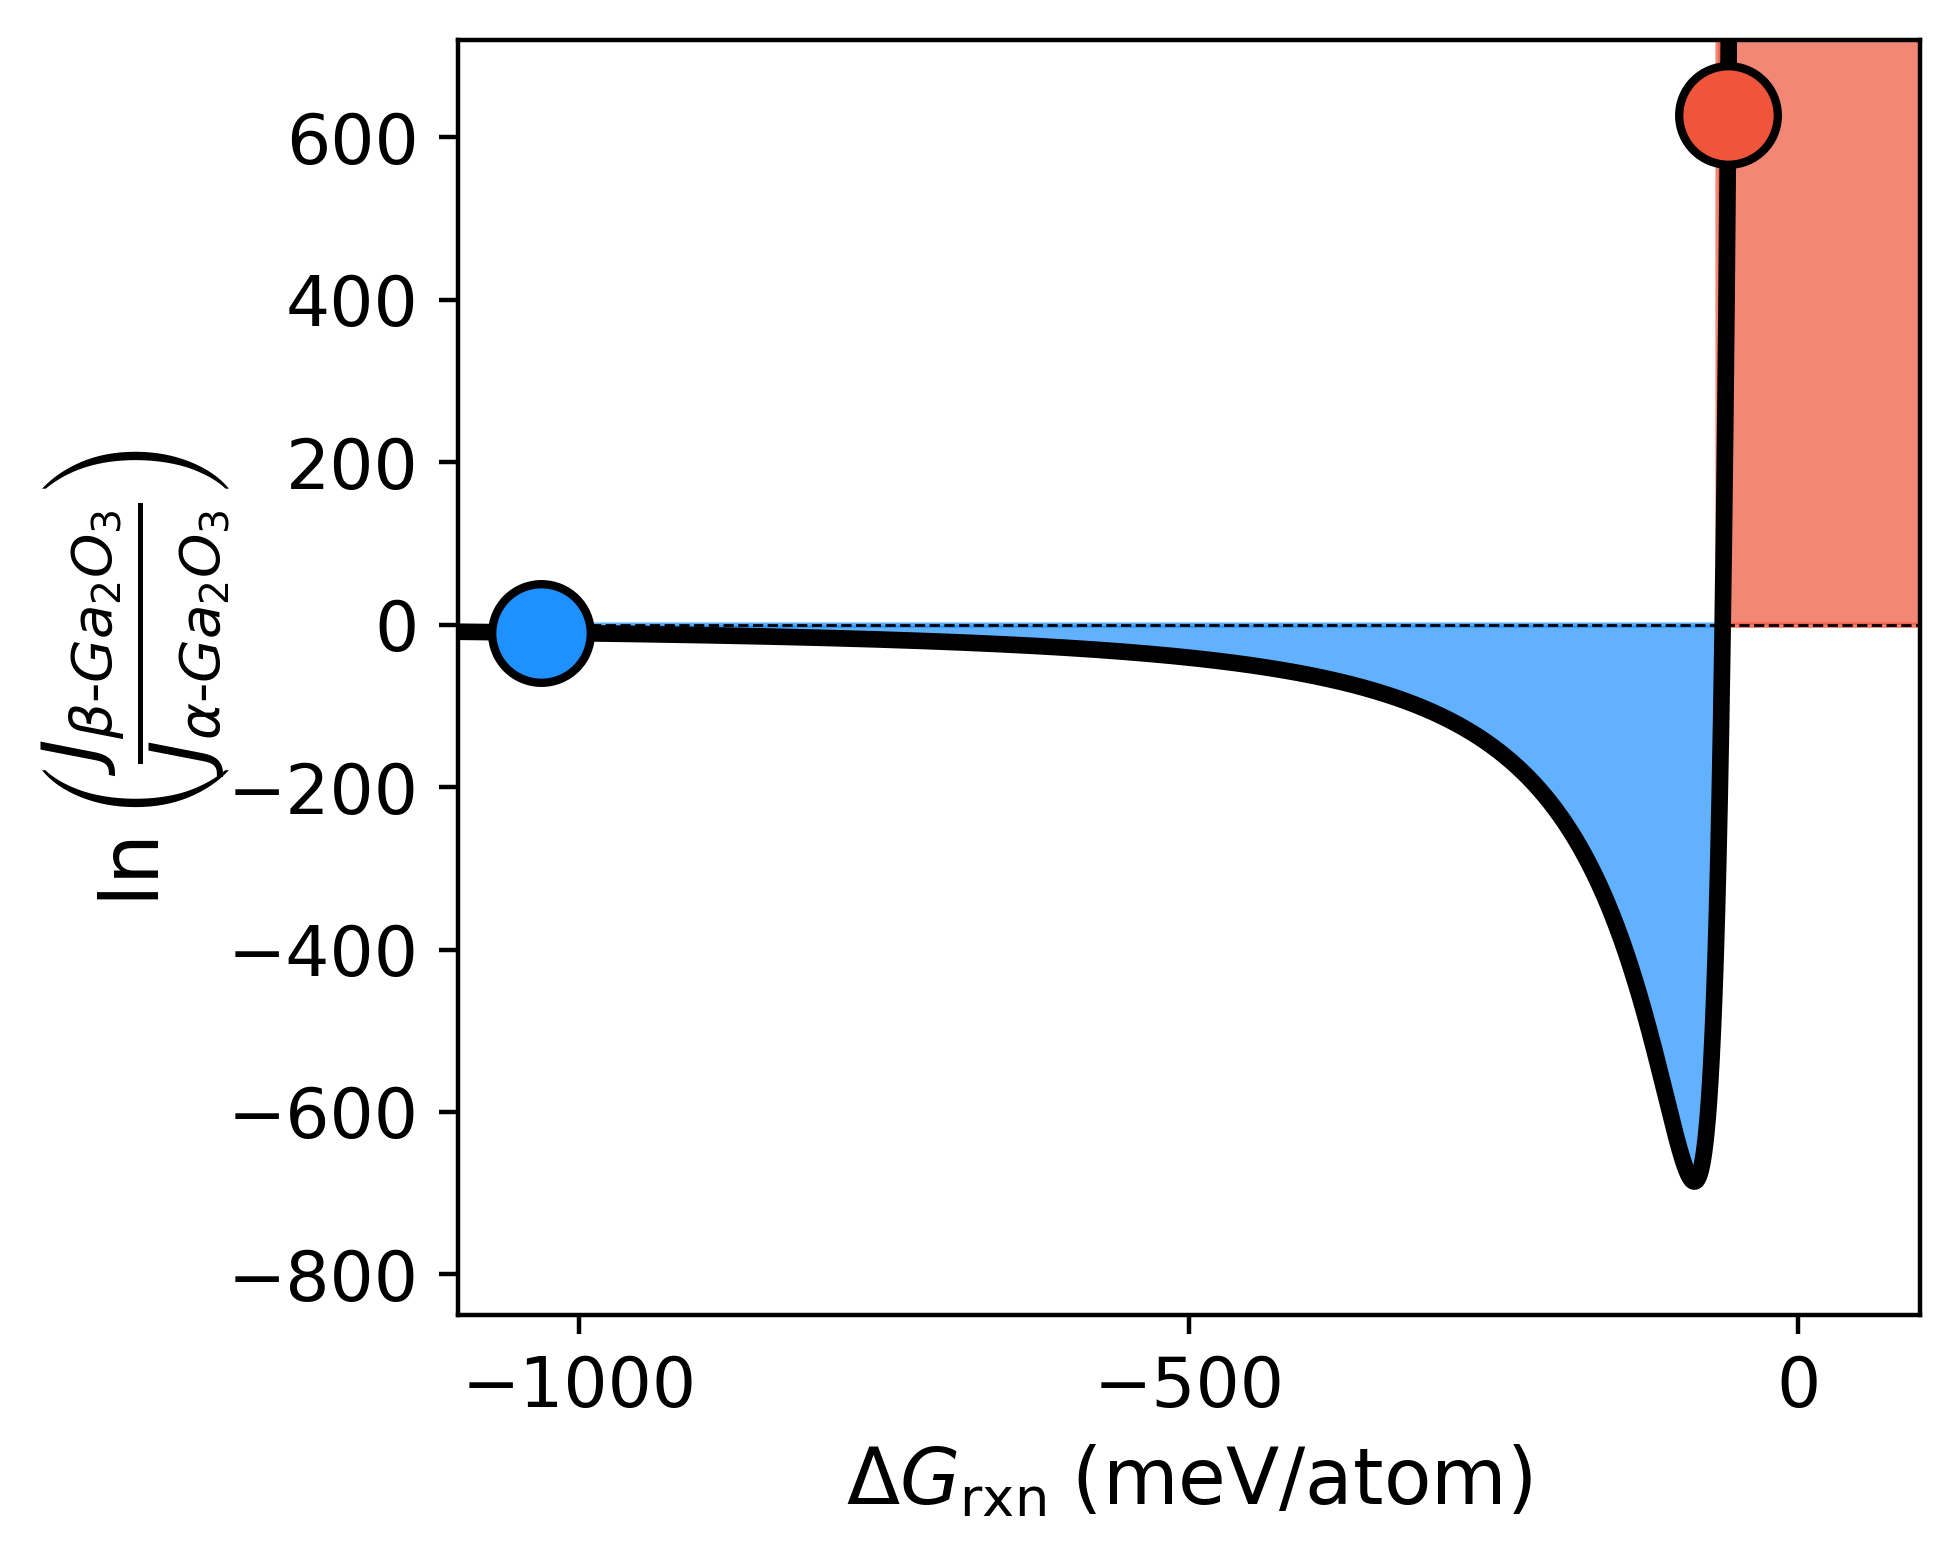

In [155]:

# -----------------------
# (b) α-Ga2O3 substrate
# -----------------------

delta_g_rxn = np.arange(-1200, -50, 0.01)
s = 315
lw = 3
fs = 14
ls = fs-1.5
xmin = -1200
xmax = 100
c1 = 'dodgerblue'
c2 = px.colors.qualitative.Plotly[1]

ymin = -850
ymax = 730
plt.figure(figsize=(5,4),dpi=400)


plt.scatter(R_2_Grxn,ln_J_ratio_R_2, zorder=3,edgecolor='black',s=s,color='dodgerblue',linewidth=1.5)
plt.scatter(R_8_Grxn,ln_J_ratio_R_8, zorder=3,edgecolor='black',s=s,color=c2,linewidth=1.5)

y2 = np.log(nucleation_rate(
    a_surface, density_a,
    b_surface - b_surface_recon + inter_b_a_Ga2O3 , density_b_a_ga2o3,
    delta_g_rxn,
    bulk_diff_a_b_ga2o3 + vib_E_diff_a_b,
    temp
))

plt.plot(delta_g_rxn, y2, color='black', linewidth=lw)
plt.axhline(0, color='k', linestyle='--', linewidth=0.5)

delta_g_rxn2 = np.arange(-1000, -66, 0.01)
y2_fill = np.log(nucleation_rate(
    a_surface, density_a,
    b_surface - b_surface_recon + inter_b_a_Ga2O3, density_b_a_ga2o3,
    delta_g_rxn2,
    bulk_diff_a_b_ga2o3 + vib_E_diff_a_b,
    temp
))
plt.fill_between(delta_g_rxn2, y2_fill,
                     color=c1, alpha=0.7,label="α-Ga$_2$O$_3$")


plt.fill_between([-66,200],[1200,800],alpha=0.7,color=c2, zorder=1,label="β-Ga$_2$O$_3$")

plt.xlim(xmin+100,xmax)
plt.ylim(ymin,ymax-10)

plt.xticks([-1000, -500, 0])
plt.tick_params(labelsize=ls)
# plt.legend()

plt.xlabel(r"$\Delta G_{\mathrm{rxn}}\;(\mathrm{meV/atom})$", fontsize=fs)

plt.ylabel(
    r"$\ln \left(\dfrac{J_{\beta\text{-}Ga_{2}O_{3}}}{J_{\alpha\text{-}Ga_{2}O_{3}}}\right)$"
,fontsize=ls+2,labelpad=-1)

plt.tight_layout()
